In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

base_path = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan"

ids = os.listdir(base_path)
print("Available IDs:", ids)

for id_name in ids:
    id_path = os.path.join(base_path, id_name)
    if os.path.isdir(id_path):
        print(f"\n{id_name} contains:")
        print(os.listdir(id_path))

Available IDs: ['id_00', 'id_02', 'id_04', 'id_06']

id_00 contains:
['abnormal', 'normal']

id_02 contains:
['abnormal', 'normal']

id_04 contains:
['abnormal', 'normal']

id_06 contains:
['abnormal', 'normal']


In [3]:
import glob

normal_files = []
abnormal_files = []

for id_name in os.listdir(base_path):
    id_path = os.path.join(base_path, id_name)

    normal_path = os.path.join(id_path, "normal")
    abnormal_path = os.path.join(id_path, "abnormal")

    normal_files += glob.glob(normal_path + "/*.wav")
    abnormal_files += glob.glob(abnormal_path + "/*.wav")

print("Total normal files:", len(normal_files))
print("Total abnormal files:", len(abnormal_files))

Total normal files: 4075
Total abnormal files: 1475


In [4]:
import librosa
import numpy as np

def wav_to_mel(file_path, sr=16000, n_mels=128):
    y, sr = librosa.load(file_path, sr=sr)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=n_mels
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    return mel_db

In [5]:
def fix_length(mel, target_frames=128):
    if mel.shape[1] < target_frames:
        pad_width = target_frames - mel.shape[1]
        mel = np.pad(mel, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel = mel[:, :target_frames]

    return mel

In [6]:
import os
import glob

base_path = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan"
target_id = "id_00"   # change if needed

id_path = os.path.join(base_path, target_id)

normal_files = glob.glob(os.path.join(id_path, "normal/*.wav"))
abnormal_files = glob.glob(os.path.join(id_path, "abnormal/*.wav"))

print("Normal files:", len(normal_files))
print("Abnormal files:", len(abnormal_files))

Normal files: 1011
Abnormal files: 407


In [7]:
import librosa
import numpy as np

def wav_to_mel(file_path, sr=16000, n_mels=128):
    y, sr = librosa.load(file_path, sr=sr)
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=n_mels
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

def fix_length(mel, target_frames=128):
    if mel.shape[1] < target_frames:
        pad_width = target_frames - mel.shape[1]
        mel = np.pad(mel, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel = mel[:, :target_frames]
    return mel

In [8]:
from sklearn.model_selection import train_test_split

# ---------- NORMAL SPLIT ----------
# 15% final test
normal_train_val, normal_test = train_test_split(
    normal_files,
    test_size=0.15,
    random_state=42
)

# From remaining 85%, take ~15% RF set
normal_train, normal_rf = train_test_split(
    normal_train_val,
    test_size=0.176,  # 0.176 × 0.85 ≈ 0.15 total
    random_state=42
)

# ---------- ABNORMAL SPLIT ----------
abnormal_rf, abnormal_test = train_test_split(
    abnormal_files,
    test_size=0.30,
    random_state=42
)

print("Normal AE train:", len(normal_train))
print("Normal RF:", len(normal_rf))
print("Normal test:", len(normal_test))

print("Abnormal RF:", len(abnormal_rf))
print("Abnormal test:", len(abnormal_test))

Normal AE train: 707
Normal RF: 152
Normal test: 152
Abnormal RF: 284
Abnormal test: 123


In [9]:
X_train = []

for file in normal_train:
    mel = wav_to_mel(file)
    mel = fix_length(mel)
    X_train.append(mel)

X_train = np.array(X_train)

# Save train normalization values
train_min = X_train.min()
train_max = X_train.max()

X_train = (X_train - train_min) / (train_max - train_min)

X_train = X_train[..., np.newaxis]

print("Train shape:", X_train.shape)

Train shape: (707, 128, 128, 1)


In [10]:
from tensorflow.keras import layers, models

input_shape = (128,128,1)
inputs = layers.Input(shape=input_shape)

# Encoder (3 pools)
x = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
encoded = layers.MaxPooling2D(2,padding='same')(x)

# Decoder (3 upsamples)
x = layers.Conv2D(64,3,activation='relu',padding='same')(encoded)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(32,3,activation='relu',padding='same')(x)
x = layers.UpSampling2D(2)(x)

outputs = layers.Conv2D(1,3,activation='sigmoid',padding='same')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse')

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=True
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - loss: 0.0187 - val_loss: 0.0036
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss: 0.0031 - val_loss: 0.0024
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - loss: 0.0024 - val_loss: 0.0022
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - loss: 0.0023 - val_loss: 0.0021
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - loss: 0.0021 - val_loss: 0.0021
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - loss: 0.0021 - val_loss: 0.0020
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - loss: 0.0020 - val_loss: 0.0020
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - loss: 0.0021 - val_loss: 0.0020
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - loss: 0.0020 - val_loss: 0.0020
Epoch 10/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - loss: 0.0021 - val_loss: 0.0019
Epoch 11/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - loss: 0.0020 - val_loss: 0.0020
Epoch 12/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - loss: 0.0020 - val_lo

In [ ]:
def prepare_dataset(file_list):
    data = []
    for file in file_list:
        mel = wav_to_mel(file)
        mel = fix_length(mel)
        data.append(mel)
    data = np.array(data)

    # Use TRAIN normalization only
    data = (data - train_min) / (train_max - train_min)

    data = data[..., np.newaxis]
    return data

X_test_normal = prepare_dataset(normal_test)
X_test_abnormal = prepare_dataset(abnormal_test)

In [ ]:
import numpy as np

recon_normal = model.predict(X_test_normal)
error_normal = np.mean(np.abs(X_test_normal - recon_normal), axis=(1,2,3))



recon_abnormal = model.predict(X_test_abnormal)
error_abnormal = np.mean(np.abs(X_test_abnormal - recon_abnormal), axis=(1,2,3))


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 311ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 315ms/step


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

y_true = np.concatenate([
    np.zeros(len(error_normal)),
    np.ones(len(error_abnormal))
])

y_scores = np.concatenate([
    error_normal,
    error_abnormal
])

auc = roc_auc_score(y_true, y_scores)
print("AUC:", auc)


AUC: 0.9045250320924262


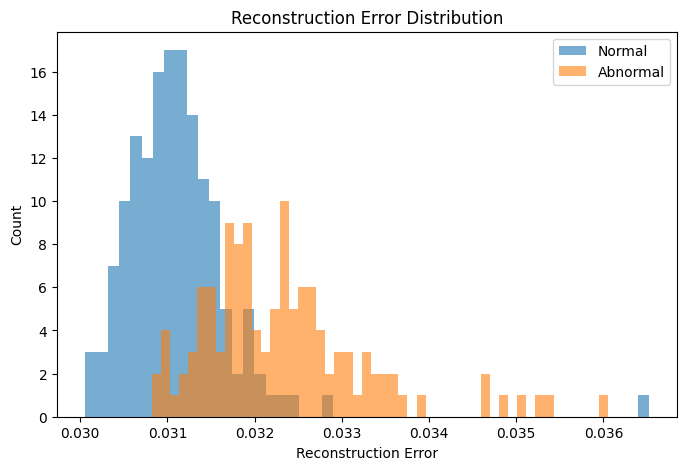

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(error_normal, bins=50, alpha=0.6, label='Normal')
plt.hist(error_abnormal, bins=50, alpha=0.6, label='Abnormal')

plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.show()


In [ ]:
threshold = np.mean(error_normal) + 3 * np.std(error_normal)
print("Threshold:", threshold)


Threshold: 0.033068325


In [ ]:
# Save model
model.save("model_id_00.keras")

# Save normalization parameters
np.save("train_min_id_00.npy", train_min)
np.save("train_max_id_00.npy", train_max)

# Save threshold
np.save("threshold_id_00.npy", threshold)

print("All deployment files saved for id_00")

All deployment files saved for id_00


In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
from tensorflow.keras.models import load_model

SR = 16000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
IMG_WIDTH = 128

model = load_model("models\CAE\model_id_00.keras")

train_min = np.load("train_min_id_00.npy").item()
train_max = np.load("train_max_id_00.npy").item()

results = []

# -----------------------------
# Feature Extraction
# -----------------------------

def extract_features(y,sr):

    centroid = np.mean(librosa.feature.spectral_centroid(y=y,sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y,sr=sr))
    energy = np.sum(y**2)

    fft = np.fft.rfft(y)
    mag = np.abs(fft)
    freqs = np.fft.rfftfreq(len(y),1/sr)

    mask = (freqs>=1000) & (freqs<=3000)

    freqs = freqs[mask]
    mag = mag[mask]

    dom = freqs[np.argmax(mag)]

    return centroid, bandwidth, energy, dom


def extract_mel(y):

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    mel = librosa.power_to_db(mel,ref=np.max)

    if mel.shape[1] < IMG_WIDTH:
        mel = np.pad(mel,((0,0),(0,IMG_WIDTH-mel.shape[1])),mode='constant')
    else:
        mel = mel[:,:IMG_WIDTH]

    return mel


# -----------------------------
# PROCESS TEST NORMAL FILES
# -----------------------------

for file in normal_rf:

    y,sr = librosa.load(file,sr=SR)

    centroid,bandwidth,energy,dom = extract_features(y,sr)

    mel = extract_mel(y)

    mel = (mel-train_min)/(train_max-train_min)

    mel = mel[...,np.newaxis]
    mel = np.expand_dims(mel,0)

    recon = model.predict(mel,verbose=0)

    error = np.mean(np.abs(mel-recon))

    results.append([
        "normal",error,centroid,bandwidth,energy,dom
    ])


# -----------------------------
# PROCESS ABNORMAL FILES
# -----------------------------

for file in abnormal_files:

    y,sr = librosa.load(file,sr=SR)

    centroid,bandwidth,energy,dom = extract_features(y,sr)

    mel = extract_mel(y)

    mel = (mel-train_min)/(train_max-train_min)

    mel = mel[...,np.newaxis]
    mel = np.expand_dims(mel,0)

    recon = model.predict(mel,verbose=0)

    error = np.mean(np.abs(mel-recon))

    results.append([
        "abnormal",error,centroid,bandwidth,energy,dom
    ])


# -----------------------------
# SAVE DATASET
# -----------------------------

df = pd.DataFrame(
    results,
    columns=[
        "condition",
        "reconstruction_error",
        "centroid",
        "bandwidth",
        "energy",
        "dominant_freq"
    ]
)

df.to_csv("id_00_features.csv",index=False)

print("id_00_features.csv created")

id_00_features.csv created


In [11]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import joblib

csv_file="data/id_00_features.csv"
data = pd.read_csv(csv_file)

X = data[
    ["reconstruction_error",
     "centroid",
     "bandwidth",
     "dominant_freq"]
]

y = data["condition"].map({"normal":0,"abnormal":1})

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',  # handles normal/abnormal imbalance
    random_state=42           # reproducibility for your report
)

rf_model.fit(X, y)

# SAVE MODEL
joblib.dump(rf_model, "id_00_fault_model.pkl")

print("Random Forest model saved")

FileNotFoundError: [Errno 2] No such file or directory: 'data/id_00_features.csv'

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_model, X, y,
    cv=cv,
    scoring='roc_auc'
)

print(f"RF CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Then train final model on full RF set for deployment
rf_model.fit(X, y)

RF CV AUC: 0.9320 ± 0.0193


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

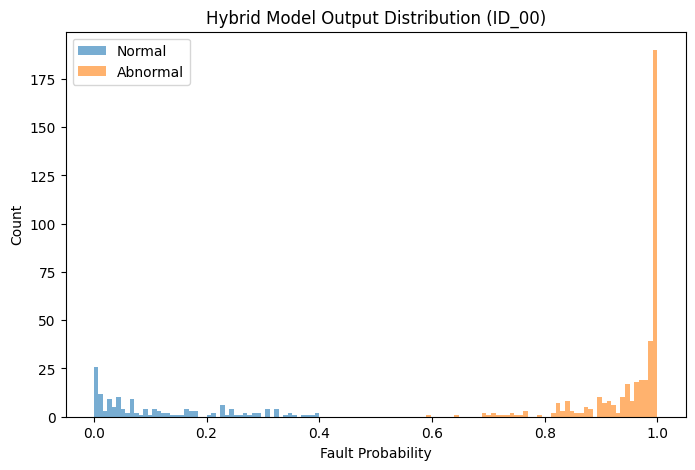

In [ ]:
import matplotlib.pyplot as plt

# predicted probability of abnormal
# Use the X data that the rf_model was trained on, along with its labels y
prob = rf_model.predict_proba(X)[:,1]

# split by label
normal_prob = prob[y == 0]
abnormal_prob = prob[y == 1]

plt.figure(figsize=(8,5))

plt.hist(normal_prob, bins=50, alpha=0.6, label="Normal")
plt.hist(abnormal_prob, bins=50, alpha=0.6, label="Abnormal")

plt.xlabel("Fault Probability")
plt.ylabel("Count")
plt.title("Hybrid Model Output Distribution (ID_00)")

plt.legend()
plt.show()

#ID_02


In [ ]:
import os
import glob

base_path = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan"
target_id = "id_02"   # change if needed

id_path = os.path.join(base_path, target_id)

normal_files = glob.glob(os.path.join(id_path, "normal/*.wav"))
abnormal_files = glob.glob(os.path.join(id_path, "abnormal/*.wav"))

print("Normal files:", len(normal_files))
print("Abnormal files:", len(abnormal_files))

Normal files: 1016
Abnormal files: 359


In [ ]:
import librosa
import numpy as np

def wav_to_mel(file_path, sr=16000, n_mels=128):
    y, sr = librosa.load(file_path, sr=sr)
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=n_mels
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

def fix_length(mel, target_frames=128):
    if mel.shape[1] < target_frames:
        pad_width = target_frames - mel.shape[1]
        mel = np.pad(mel, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel = mel[:, :target_frames]
    return mel


In [ ]:
from sklearn.model_selection import train_test_split

# ---------- NORMAL SPLIT ----------
# 15% final test
normal_train_val, normal_test = train_test_split(
    normal_files,
    test_size=0.15,
    random_state=42
)

# From remaining 85%, take ~15% RF set
normal_train, normal_rf = train_test_split(
    normal_train_val,
    test_size=0.176,  # 0.176 × 0.85 ≈ 0.15 total
    random_state=42
)

# ---------- ABNORMAL SPLIT ----------
abnormal_rf, abnormal_test = train_test_split(
    abnormal_files,
    test_size=0.30,
    random_state=42
)

print("Normal AE train:", len(normal_train))
print("Normal RF:", len(normal_rf))
print("Normal test:", len(normal_test))

print("Abnormal RF:", len(abnormal_rf))
print("Abnormal test:", len(abnormal_test))

In [ ]:
X_train = []

for file in normal_train:
    mel = wav_to_mel(file)
    mel = fix_length(mel)
    X_train.append(mel)

X_train = np.array(X_train)

# Save train normalization values
train_min = X_train.min()
train_max = X_train.max()

X_train = (X_train - train_min) / (train_max - train_min)

X_train = X_train[..., np.newaxis]

print("Train shape:", X_train.shape)

Train shape: (1016, 128, 128, 1)


In [ ]:
from tensorflow.keras import layers, models

input_shape = (128,128,1)
inputs = layers.Input(shape=input_shape)

# Encoder (3 pools)
x = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
encoded = layers.MaxPooling2D(2,padding='same')(x)

# Decoder (3 upsamples)
x = layers.Conv2D(64,3,activation='relu',padding='same')(encoded)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(32,3,activation='relu',padding='same')(x)
x = layers.UpSampling2D(2)(x)

outputs = layers.Conv2D(1,3,activation='sigmoid',padding='same')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse')


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=True
)


Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - loss: 0.0166 - val_loss: 0.0043
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0041 - val_loss: 0.0039
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0038 - val_loss: 0.0036
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0036 - val_loss: 0.0035
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0035 - val_loss: 0.0034
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0034 - val_loss: 0.0034
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0033 - val_loss: 0.0033
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0033 - val_loss: 0.0032
Epoch 9/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0032 - val_loss: 0.0032
Epoch 10/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0032 - val_loss: 0.0032
Epoch 11/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0032 - val_loss: 0.0031
Epoch 12/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.

In [ ]:
def prepare_dataset(file_list):
    data = []
    for file in file_list:
        mel = wav_to_mel(file)
        mel = fix_length(mel)
        data.append(mel)
    data = np.array(data)

    # Use TRAIN normalization only
    data = (data - train_min) / (train_max - train_min)

    data = data[..., np.newaxis]
    return data

X_test_normal = prepare_dataset(normal_test)
X_test_abnormal = prepare_dataset(abnormal_test)


In [ ]:
import numpy as np

recon_normal = model.predict(X_test_normal)
error_normal = np.mean(np.abs(X_test_normal - recon_normal), axis=(1,2,3))



recon_abnormal = model.predict(X_test_abnormal)
error_abnormal = np.mean(np.abs(X_test_abnormal - recon_abnormal), axis=(1,2,3))


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

y_true = np.concatenate([
    np.zeros(len(error_normal)),
    np.ones(len(error_abnormal))
])

y_scores = np.concatenate([
    error_normal,
    error_abnormal
])

auc = roc_auc_score(y_true, y_scores)
print("AUC:", auc)


AUC: 0.9763642445112188


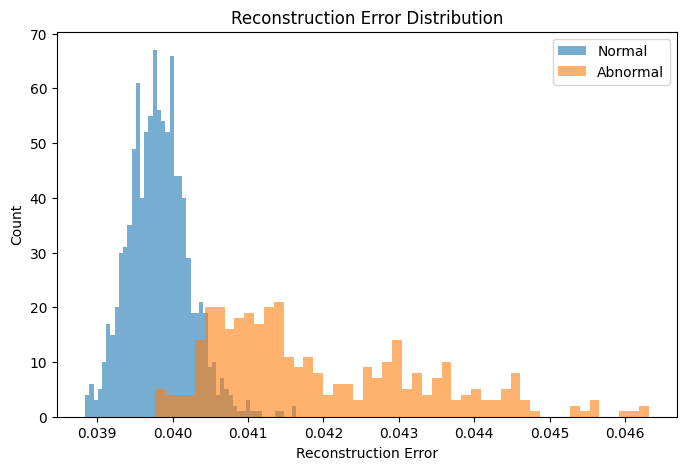

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(error_normal, bins=50, alpha=0.6, label='Normal')
plt.hist(error_abnormal, bins=50, alpha=0.6, label='Abnormal')

plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.show()


In [ ]:
threshold = np.mean(error_normal) + 3 * np.std(error_normal)
print("Threshold:", threshold)

Threshold: 0.041015577


In [ ]:
model.save("model_id_02.keras")
np.save("train_min_id_02.npy", train_min)
np.save("train_max_id_02.npy", train_max)
np.save("threshold_id_02.npy", threshold)

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
from tensorflow.keras.models import load_model

SR = 16000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
IMG_WIDTH = 128

model = load_model("model_id_02.keras")

train_min = np.load("train_min_id_02.npy").item()
train_max = np.load("train_max_id_02.npy").item()

results = []

# -----------------------------
# Feature Extraction
# -----------------------------

def extract_features(y,sr):

    centroid = np.mean(librosa.feature.spectral_centroid(y=y,sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y,sr=sr))
    energy = np.sum(y**2)

    fft = np.fft.rfft(y)
    mag = np.abs(fft)
    freqs = np.fft.rfftfreq(len(y),1/sr)

    mask = (freqs>=1000) & (freqs<=3000)

    freqs = freqs[mask]
    mag = mag[mask]

    dom = freqs[np.argmax(mag)]

    return centroid, bandwidth, energy, dom


def extract_mel(y):

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    mel = librosa.power_to_db(mel,ref=np.max)

    if mel.shape[1] < IMG_WIDTH:
        mel = np.pad(mel,((0,0),(0,IMG_WIDTH-mel.shape[1])),mode='constant')
    else:
        mel = mel[:,:IMG_WIDTH]

    return mel


# -----------------------------
# PROCESS TEST NORMAL FILES
# -----------------------------

for file in normal_rf:

    y,sr = librosa.load(file,sr=SR)

    centroid,bandwidth,energy,dom = extract_features(y,sr)

    mel = extract_mel(y)

    mel = (mel-train_min)/(train_max-train_min)

    mel = mel[...,np.newaxis]
    mel = np.expand_dims(mel,0)

    recon = model.predict(mel,verbose=0)

    error = np.mean(np.abs(mel-recon))

    results.append([
        "normal",error,centroid,bandwidth,energy,dom
    ])


# -----------------------------
# PROCESS ABNORMAL FILES
# -----------------------------

for file in abnormal_files:

    y,sr = librosa.load(file,sr=SR)

    centroid,bandwidth,energy,dom = extract_features(y,sr)

    mel = extract_mel(y)

    mel = (mel-train_min)/(train_max-train_min)

    mel = mel[...,np.newaxis]
    mel = np.expand_dims(mel,0)

    recon = model.predict(mel,verbose=0)

    error = np.mean(np.abs(mel-recon))

    results.append([
        "abnormal",error,centroid,bandwidth,energy,dom
    ])


# -----------------------------
# SAVE DATASET
# -----------------------------

df = pd.DataFrame(
    results,
    columns=[
        "condition",
        "reconstruction_error",
        "centroid",
        "bandwidth",
        "energy",
        "dominant_freq"
    ]
)

df.to_csv("id_02_features.csv",index=False)

print("id_02_features.csv created")

id_02_features.csv created


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import joblib

data = pd.read_csv("id_02_features.csv")

X = data[
    ["reconstruction_error",
     "centroid",
     "bandwidth",
     "dominant_freq"]
]

y = data["condition"].map({"normal":0,"abnormal":1})

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',  # handles normal/abnormal imbalance
    random_state=42           # reproducibility for your report
)

rf_model.fit(X, y)

# SAVE MODEL
joblib.dump(rf_model, "id_02_fault_model.pkl")

print("Random Forest model saved")

Random Forest model saved


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_model, X, y,
    cv=cv,
    scoring='roc_auc'
)

print(f"RF CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Then train final model on full RF set for deployment
rf_model.fit(X, y)

AUC: 0.9990333333333334


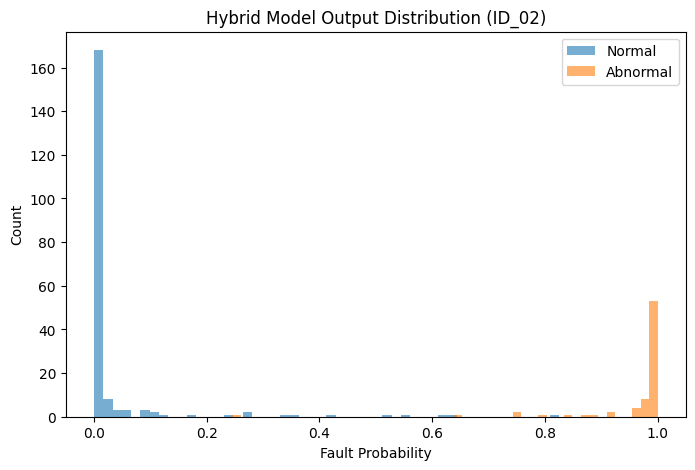

In [ ]:
import matplotlib.pyplot as plt

# predicted probability of abnormal
# Use the X data that the rf_model was trained on, along with its labels y
prob = rf_model.predict_proba(X)[:,1]

# split by label
normal_prob = prob[y == 0]
abnormal_prob = prob[y == 1]

plt.figure(figsize=(8,5))

plt.hist(normal_prob, bins=50, alpha=0.6, label="Normal")
plt.hist(abnormal_prob, bins=50, alpha=0.6, label="Abnormal")

plt.xlabel("Fault Probability")
plt.ylabel("Count")
plt.title("Hybrid Model Output Distribution (ID_00)")

plt.legend()
plt.show()

#ID_04

In [ ]:
import os
import glob

base_path = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan"
target_id = "id_04"   # change if needed

id_path = os.path.join(base_path, target_id)

normal_files = glob.glob(os.path.join(id_path, "normal/*.wav"))
abnormal_files = glob.glob(os.path.join(id_path, "abnormal/*.wav"))

print("Normal files:", len(normal_files))
print("Abnormal files:", len(abnormal_files))

Normal files: 1033
Abnormal files: 348


In [ ]:
import librosa
import numpy as np

def wav_to_mel(file_path, sr=16000, n_mels=128):
    y, sr = librosa.load(file_path, sr=sr)
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=n_mels
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

def fix_length(mel, target_frames=128):
    if mel.shape[1] < target_frames:
        pad_width = target_frames - mel.shape[1]
        mel = np.pad(mel, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel = mel[:, :target_frames]
    return mel

In [ ]:
from sklearn.model_selection import train_test_split

# ---------- NORMAL SPLIT ----------
# 15% final test
normal_train_val, normal_test = train_test_split(
    normal_files,
    test_size=0.15,
    random_state=42
)

# From remaining 85%, take ~15% RF set
normal_train, normal_rf = train_test_split(
    normal_train_val,
    test_size=0.176,  # 0.176 × 0.85 ≈ 0.15 total
    random_state=42
)

# ---------- ABNORMAL SPLIT ----------
abnormal_rf, abnormal_test = train_test_split(
    abnormal_files,
    test_size=0.30,
    random_state=42
)

print("Normal AE train:", len(normal_train))
print("Normal RF:", len(normal_rf))
print("Normal test:", len(normal_test))

print("Abnormal RF:", len(abnormal_rf))
print("Abnormal test:", len(abnormal_test))

In [ ]:
X_train = []

for file in normal_train:
    mel = wav_to_mel(file)
    mel = fix_length(mel)
    X_train.append(mel)

X_train = np.array(X_train)

# Save train normalization values
train_min = X_train.min()
train_max = X_train.max()

X_train = (X_train - train_min) / (train_max - train_min)

X_train = X_train[..., np.newaxis]

print("Train shape:", X_train.shape)

Train shape: (1033, 128, 128, 1)


In [ ]:
from tensorflow.keras import layers, models

input_shape = (128,128,1)
inputs = layers.Input(shape=input_shape)

# Encoder (3 pools)
x = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
encoded = layers.MaxPooling2D(2,padding='same')(x)

# Decoder (3 upsamples)
x = layers.Conv2D(64,3,activation='relu',padding='same')(encoded)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(32,3,activation='relu',padding='same')(x)
x = layers.UpSampling2D(2)(x)

outputs = layers.Conv2D(1,3,activation='sigmoid',padding='same')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse')

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=True
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - loss: 0.0175 - val_loss: 0.0037
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0034 - val_loss: 0.0031
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0030 - val_loss: 0.0032
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0029 - val_loss: 0.0028
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0026 - val_loss: 0.0025
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 12/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0

In [ ]:
def prepare_dataset(file_list):
    data = []
    for file in file_list:
        mel = wav_to_mel(file)
        mel = fix_length(mel)
        data.append(mel)
    data = np.array(data)

    # Use TRAIN normalization only
    data = (data - train_min) / (train_max - train_min)

    data = data[..., np.newaxis]
    return data


X_test_normal = prepare_dataset(normal_test)
X_test_abnormal = prepare_dataset(abnormal_test)

In [ ]:
import numpy as np

recon_normal = model.predict(X_test_normal)
error_normal = np.mean(np.abs(X_test_normal - recon_normal), axis=(1,2,3))



recon_abnormal = model.predict(X_test_abnormal)
error_abnormal = np.mean(np.abs(X_test_abnormal - recon_abnormal), axis=(1,2,3))

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

y_true = np.concatenate([
    np.zeros(len(error_normal)),
    np.ones(len(error_abnormal))
])

y_scores = np.concatenate([
    error_normal,
    error_abnormal
])

auc = roc_auc_score(y_true, y_scores)
print("AUC:", auc)

AUC: 0.8938450668179947


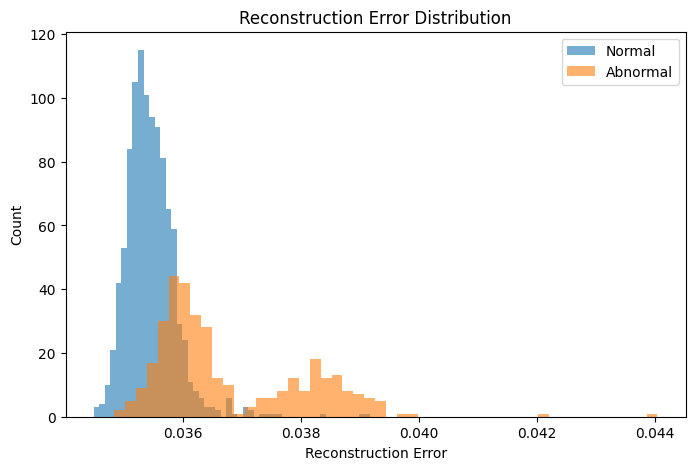

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(error_normal, bins=50, alpha=0.6, label='Normal')
plt.hist(error_abnormal, bins=50, alpha=0.6, label='Abnormal')

plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.show()

In [ ]:
threshold = np.mean(error_normal) + 3 * np.std(error_normal)
print("Threshold:", threshold)

Threshold: 0.036770437


In [ ]:
model.save("model_id_04.keras")
np.save("train_min_id_04.npy", train_min)
np.save("train_max_id_04.npy", train_max)
np.save("threshold_id_04.npy", threshold)

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
from tensorflow.keras.models import load_model

SR = 16000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
IMG_WIDTH = 128

model = load_model("model_id_04.keras")

train_min = np.load("train_min_id_04.npy").item()
train_max = np.load("train_max_id_04.npy").item()

results = []

# -----------------------------
# Feature Extraction
# -----------------------------

def extract_features(y,sr):

    centroid = np.mean(librosa.feature.spectral_centroid(y=y,sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y,sr=sr))
    energy = np.sum(y**2)

    fft = np.fft.rfft(y)
    mag = np.abs(fft)
    freqs = np.fft.rfftfreq(len(y),1/sr)

    mask = (freqs>=1000) & (freqs<=3000)

    freqs = freqs[mask]
    mag = mag[mask]

    dom = freqs[np.argmax(mag)]

    return centroid, bandwidth, energy, dom


def extract_mel(y):

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    mel = librosa.power_to_db(mel,ref=np.max)

    if mel.shape[1] < IMG_WIDTH:
        mel = np.pad(mel,((0,0),(0,IMG_WIDTH-mel.shape[1])),mode='constant')
    else:
        mel = mel[:,:IMG_WIDTH]

    return mel


# -----------------------------
# PROCESS TEST NORMAL FILES
# -----------------------------

for file in normal_rf:

    y,sr = librosa.load(file,sr=SR)

    centroid,bandwidth,energy,dom = extract_features(y,sr)

    mel = extract_mel(y)

    mel = (mel-train_min)/(train_max-train_min)

    mel = mel[...,np.newaxis]
    mel = np.expand_dims(mel,0)

    recon = model.predict(mel,verbose=0)

    error = np.mean(np.abs(mel-recon))

    results.append([
        "normal",error,centroid,bandwidth,energy,dom
    ])


# -----------------------------
# PROCESS ABNORMAL FILES
# -----------------------------

for file in abnormal_files:

    y,sr = librosa.load(file,sr=SR)

    centroid,bandwidth,energy,dom = extract_features(y,sr)

    mel = extract_mel(y)

    mel = (mel-train_min)/(train_max-train_min)

    mel = mel[...,np.newaxis]
    mel = np.expand_dims(mel,0)

    recon = model.predict(mel,verbose=0)

    error = np.mean(np.abs(mel-recon))

    results.append([
        "abnormal",error,centroid,bandwidth,energy,dom
    ])


# -----------------------------
# SAVE DATASET
# -----------------------------

df = pd.DataFrame(
    results,
    columns=[
        "condition",
        "reconstruction_error",
        "centroid",
        "bandwidth",
        "energy",
        "dominant_freq"
    ]
)

df.to_csv("id_04_features.csv",index=False)

print("id_04_features.csv created")

id_02_features.csv created


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import joblib

data = pd.read_csv("id_04_features.csv")

X = data[
    ["reconstruction_error",
     "centroid",
     "bandwidth",
     "dominant_freq"]
]

y = data["condition"].map({"normal":0,"abnormal":1})

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',  # handles normal/abnormal imbalance
    random_state=42           # reproducibility for your report
)

rf_model.fit(X, y)

# SAVE MODEL
joblib.dump(rf_model, "id_04_fault_model.pkl")

print("Random Forest model saved")

Random Forest model saved


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_model, X, y,
    cv=cv,
    scoring='roc_auc'
)

print(f"RF CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Then train final model on full RF set for deployment
rf_model.fit(X, y)

AUC: 0.9990333333333334


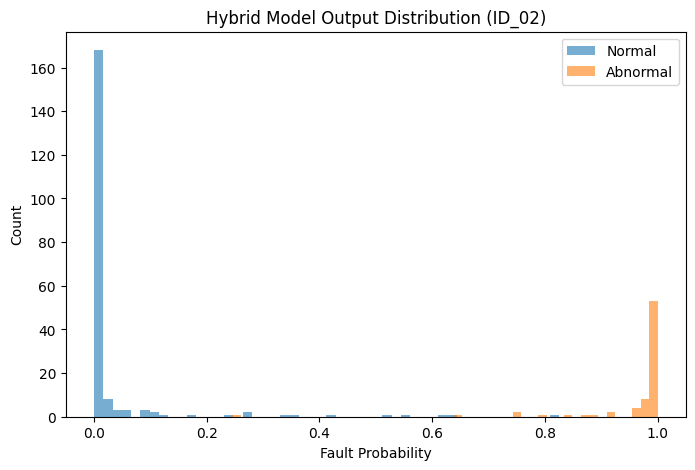

In [ ]:
import matplotlib.pyplot as plt

# predicted probability of abnormal
# Use the X data that the rf_model was trained on, along with its labels y
prob = rf_model.predict_proba(X)[:,1]

# split by label
normal_prob = prob[y == 0]
abnormal_prob = prob[y == 1]

plt.figure(figsize=(8,5))

plt.hist(normal_prob, bins=50, alpha=0.6, label="Normal")
plt.hist(abnormal_prob, bins=50, alpha=0.6, label="Abnormal")

plt.xlabel("Fault Probability")
plt.ylabel("Count")
plt.title("Hybrid Model Output Distribution (ID_00)")

plt.legend()
plt.show()

# ID_06

In [ ]:
import os
import glob

base_path = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan"
target_id = "id_06"   # change if needed

id_path = os.path.join(base_path, target_id)

normal_files = glob.glob(os.path.join(id_path, "normal/*.wav"))
abnormal_files = glob.glob(os.path.join(id_path, "abnormal/*.wav"))

print("Normal files:", len(normal_files))
print("Abnormal files:", len(abnormal_files))

Normal files: 1015
Abnormal files: 361


In [ ]:
import librosa
import numpy as np

def wav_to_mel(file_path, sr=16000, n_mels=128):
    y, sr = librosa.load(file_path, sr=sr)
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=n_mels
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

def fix_length(mel, target_frames=128):
    if mel.shape[1] < target_frames:
        pad_width = target_frames - mel.shape[1]
        mel = np.pad(mel, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel = mel[:, :target_frames]
    return mel

In [ ]:
from sklearn.model_selection import train_test_split

# ---------- NORMAL SPLIT ----------
# 15% final test
normal_train_val, normal_test = train_test_split(
    normal_files,
    test_size=0.15,
    random_state=42
)

# From remaining 85%, take ~15% RF set
normal_train, normal_rf = train_test_split(
    normal_train_val,
    test_size=0.176,  # 0.176 × 0.85 ≈ 0.15 total
    random_state=42
)

# ---------- ABNORMAL SPLIT ----------
abnormal_rf, abnormal_test = train_test_split(
    abnormal_files,
    test_size=0.30,
    random_state=42
)

print("Normal AE train:", len(normal_train))
print("Normal RF:", len(normal_rf))
print("Normal test:", len(normal_test))

print("Abnormal RF:", len(abnormal_rf))
print("Abnormal test:", len(abnormal_test))

Normal AE train: 710
Normal RF: 152
Normal test: 153
Abnormal RF: 252
Abnormal test: 109


In [ ]:
X_train = []

from sklearn.model_selection import train_test_split

for file in normal_train:
    mel = wav_to_mel(file)
    mel = fix_length(mel)
    X_train.append(mel)

X_train = np.array(X_train)

# Save train normalization values
train_min = X_train.min()
train_max = X_train.max()

X_train = (X_train - train_min) / (train_max - train_min)

X_train = X_train[..., np.newaxis]

print("Train shape:", X_train.shape)

Train shape: (710, 128, 128, 1)


In [ ]:
from tensorflow.keras import layers, models

input_shape = (128,128,1)
inputs = layers.Input(shape=input_shape)

# Encoder (3 pools)
x = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
encoded = layers.MaxPooling2D(2,padding='same')(x)

# Decoder (3 upsamples)
x = layers.Conv2D(64,3,activation='relu',padding='same')(encoded)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(32,3,activation='relu',padding='same')(x)
x = layers.UpSampling2D(2)(x)

outputs = layers.Conv2D(1,3,activation='sigmoid',padding='same')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse')

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=True
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 169ms/step - loss: 0.0193 - val_loss: 0.0074
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0058 - val_loss: 0.0039
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0039 - val_loss: 0.0033
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0033 - val_loss: 0.0031
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 10/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 11/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 12/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0

In [ ]:
def prepare_dataset(file_list):
    data = []
    for file in file_list:
        mel = wav_to_mel(file)
        mel = fix_length(mel)
        data.append(mel)
    data = np.array(data)

    # Use TRAIN normalization only
    data = (data - train_min) / (train_max - train_min)

    data = data[..., np.newaxis]
    return data


X_test_normal = prepare_dataset(normal_test)
X_test_abnormal = prepare_dataset(abnormal_test)

In [ ]:
import numpy as np

recon_normal = model.predict(X_test_normal)
error_normal = np.mean(np.abs(X_test_normal - recon_normal), axis=(1,2,3))



recon_abnormal = model.predict(X_test_abnormal)
error_abnormal = np.mean(np.abs(X_test_abnormal - recon_abnormal), axis=(1,2,3))

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 322ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 249ms/step


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

y_true = np.concatenate([
    np.zeros(len(error_normal)),
    np.ones(len(error_abnormal))
])

y_scores = np.concatenate([
    error_normal,
    error_abnormal
])

auc = roc_auc_score(y_true, y_scores)
print("AUC:", auc)

AUC: 0.9785932721712538


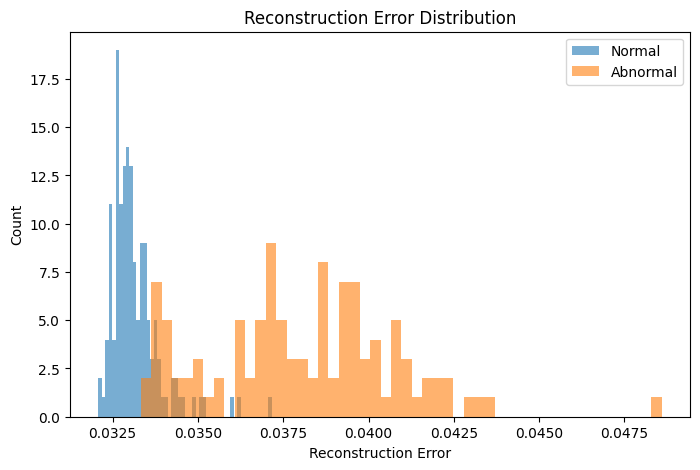

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(error_normal, bins=50, alpha=0.6, label='Normal')
plt.hist(error_abnormal, bins=50, alpha=0.6, label='Abnormal')

plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.show()

In [ ]:
threshold = np.mean(error_normal) + 3 * np.std(error_normal)
print("Threshold:", threshold)

Threshold: 0.03406999


In [ ]:
model.save("model_id_06.keras")
np.save("train_min_id_06.npy", train_min)
np.save("train_max_id_06.npy", train_max)
np.save("threshold_id_06.npy", threshold)

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
from tensorflow.keras.models import load_model

SR = 16000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
IMG_WIDTH = 128

model = load_model("model_id_06.keras")

train_min = np.load("train_min_id_06.npy").item()
train_max = np.load("train_max_id_06.npy").item()

results = []

# -----------------------------
# Feature Extraction
# -----------------------------

def extract_features(y,sr):

    centroid = np.mean(librosa.feature.spectral_centroid(y=y,sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y,sr=sr))
    energy = np.sum(y**2)

    fft = np.fft.rfft(y)
    mag = np.abs(fft)
    freqs = np.fft.rfftfreq(len(y),1/sr)

    mask = (freqs>=1000) & (freqs<=3000)

    freqs = freqs[mask]
    mag = mag[mask]

    dom = freqs[np.argmax(mag)]

    return centroid, bandwidth, energy, dom


def extract_mel(y):

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    mel = librosa.power_to_db(mel,ref=np.max)

    if mel.shape[1] < IMG_WIDTH:
        mel = np.pad(mel,((0,0),(0,IMG_WIDTH-mel.shape[1])),mode='constant')
    else:
        mel = mel[:,:IMG_WIDTH]

    return mel


# -----------------------------
# PROCESS TEST NORMAL FILES
# -----------------------------

for file in normal_rf:

    y,sr = librosa.load(file,sr=SR)

    centroid,bandwidth,energy,dom = extract_features(y,sr)

    mel = extract_mel(y)

    mel = (mel-train_min)/(train_max-train_min)

    mel = mel[...,np.newaxis]
    mel = np.expand_dims(mel,0)

    recon = model.predict(mel,verbose=0)

    error = np.mean(np.abs(mel-recon))

    results.append([
        "normal",error,centroid,bandwidth,energy,dom
    ])


# -----------------------------
# PROCESS ABNORMAL FILES
# -----------------------------

for file in abnormal_files:

    y,sr = librosa.load(file,sr=SR)

    centroid,bandwidth,energy,dom = extract_features(y,sr)

    mel = extract_mel(y)

    mel = (mel-train_min)/(train_max-train_min)

    mel = mel[...,np.newaxis]
    mel = np.expand_dims(mel,0)

    recon = model.predict(mel,verbose=0)

    error = np.mean(np.abs(mel-recon))

    results.append([
        "abnormal",error,centroid,bandwidth,energy,dom
    ])


# -----------------------------
# SAVE DATASET
# -----------------------------

df = pd.DataFrame(
    results,
    columns=[
        "condition",
        "reconstruction_error",
        "centroid",
        "bandwidth",
        "energy",
        "dominant_freq"
    ]
)

df.to_csv("id_06_features.csv",index=False)

print("id_06_features.csv created")

id_06_features.csv created


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import joblib

data = pd.read_csv("id_06_features.csv")

X = data[
    ["reconstruction_error",
     "centroid",
     "bandwidth",
     "dominant_freq"]
]

y = data["condition"].map({"normal":0,"abnormal":1})

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',  # handles normal/abnormal imbalance
    random_state=42           # reproducibility for your report
)

rf_model.fit(X, y)

# SAVE MODEL
joblib.dump(rf_model, "id_06_fault_model.pkl")

print("Random Forest model saved")

Random Forest model saved


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_model, X, y,
    cv=cv,
    scoring='roc_auc'
)

print(f"RF CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Then train final model on full RF set for deployment
rf_model.fit(X, y)

RF CV AUC: 0.9959 ± 0.0075


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = ["reconstruction_error", "centroid", "bandwidth", "energy", "dominant_freq"]
importances = rf_model.feature_importances_

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False)
print(fi_df)

fi_df.plot(kind='bar', x='feature', y='importance')
plt.tight_layout()
plt.show()

ValueError: All arrays must be of the same length

In [ ]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

test_results = []

# -----------------------------
# NORMAL TEST FILES
# -----------------------------
for file in normal_test:

    y, sr = librosa.load(file, sr=SR)

    centroid, bandwidth, energy, dom = extract_features(y, sr)

    mel = extract_mel(y)
    mel = (mel - train_min) / (train_max - train_min)

    mel = mel[..., np.newaxis]
    mel = np.expand_dims(mel, 0)

    recon = model.predict(mel, verbose=0)

    error = np.mean(np.abs(mel - recon))

    test_results.append(["normal", error, centroid, bandwidth, energy, dom])


# -----------------------------
# ABNORMAL TEST FILES
# -----------------------------
for file in abnormal_test:

    y, sr = librosa.load(file, sr=SR)

    centroid, bandwidth, energy, dom = extract_features(y, sr)

    mel = extract_mel(y)
    mel = (mel - train_min) / (train_max - train_min)

    mel = mel[..., np.newaxis]
    mel = np.expand_dims(mel, 0)

    recon = model.predict(mel, verbose=0)

    error = np.mean(np.abs(mel - recon))

    test_results.append(["abnormal", error, centroid, bandwidth, energy, dom])


# -----------------------------
# BUILD TEST DATASET
# -----------------------------

df_test = pd.DataFrame(
    test_results,
    columns=[
        "condition",
        "reconstruction_error",
        "centroid",
        "bandwidth",
        "energy",
        "dominant_freq"
    ]
)

X_final = df_test[
    ["reconstruction_error","centroid","bandwidth","energy","dominant_freq"]
]

y_final = df_test["condition"].map({"normal":0,"abnormal":1})


# -----------------------------
# RF PREDICTION
# -----------------------------

prob = rf_model.predict_proba(X_final)[:,1]


# -----------------------------
# AUC
# -----------------------------

auc = roc_auc_score(y_final, prob)

print("Final Held-Out AUC:", auc)

Final Held-Out AUC: 1.0


In [ ]:
import joblib
from sklearn.metrics import roc_auc_score

# -----------------------------
# LOAD RF MODEL
# -----------------------------

rf_model = joblib.load("id_06_fault_model.pkl")


# -----------------------------
# PREPARE TEST DATA
# -----------------------------

df_test = pd.DataFrame(
    test_results,
    columns=[
        "condition",
        "reconstruction_error",
        "centroid",
        "bandwidth",
        "energy",
        "dominant_freq"
    ]
)

X_test = df_test[
    ["reconstruction_error","centroid","bandwidth","dominant_freq"]
]

y_test = df_test["condition"].map({"normal":0,"abnormal":1})


# -----------------------------
# PREDICT PROBABILITIES
# -----------------------------

pred = rf_model.predict_proba(X_test)[:,1]


# -----------------------------
# CALCULATE AUC
# -----------------------------

auc = roc_auc_score(y_test, pred)

print("Final Held-Out AUC:", auc)

Final Held-Out AUC: 0.9877675840978594


In [ ]:
# Step 1 - Rebuild feature set WITHOUT energy
data = pd.read_csv("id_06_features.csv")

X = data[["reconstruction_error", "centroid", "bandwidth", "dominant_freq"]]  # no energy
y = data["condition"].map({"normal": 0, "abnormal": 1})

# Step 2 - Retrain RF on RF split data only
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X, y)

# Step 3 - Save the NEW model
joblib.dump(rf_model, "id_06_fault_model_v2.pkl")

# Step 4 - Evaluate on held-out test with SAME 4 features
X_test = df_test[["reconstruction_error", "centroid", "bandwidth", "dominant_freq"]]
y_test = df_test["condition"].map({"normal": 0, "abnormal": 1})

pred = rf_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, pred)
print("Clean AUC:", auc)

Clean AUC: 0.9877675840978594


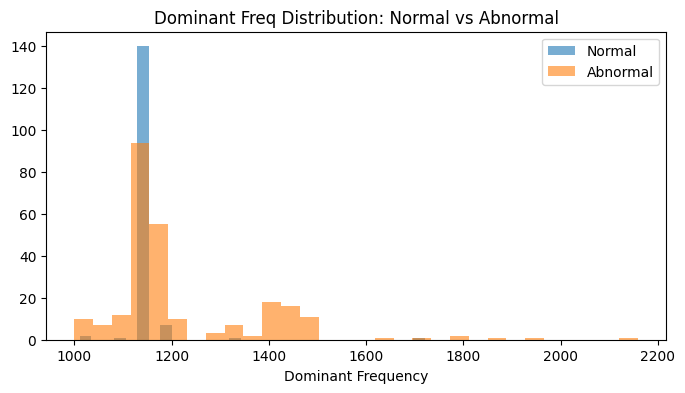

In [ ]:
normal_dom = []
abnormal_dom = []

for file in normal_rf:
    y, sr = librosa.load(file, sr=SR)
    fft = np.fft.rfft(y)
    mag = np.abs(fft)
    freqs = np.fft.rfftfreq(len(y), 1/sr)
    mask = (freqs >= 1000) & (freqs <= 3000)
    normal_dom.append(freqs[mask][np.argmax(mag[mask])])

for file in abnormal_rf:
    y, sr = librosa.load(file, sr=SR)
    fft = np.fft.rfft(y)
    mag = np.abs(fft)
    freqs = np.fft.rfftfreq(len(y), 1/sr)
    mask = (freqs >= 1000) & (freqs <= 3000)
    abnormal_dom.append(freqs[mask][np.argmax(mag[mask])])

plt.figure(figsize=(8,4))
plt.hist(normal_dom, bins=30, alpha=0.6, label='Normal')
plt.hist(abnormal_dom, bins=30, alpha=0.6, label='Abnormal')
plt.xlabel("Dominant Frequency")
plt.legend()
plt.title("Dominant Freq Distribution: Normal vs Abnormal")
plt.show()

In [ ]:
# Test with ONLY reconstruction error
X_solo = data[["reconstruction_error"]]
y = data["condition"].map({"normal": 0, "abnormal": 1})

from sklearn.model_selection import StratifiedKFold, cross_val_score

rf_solo = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

solo_auc = cross_val_score(rf_solo, X_solo, y, cv=cv, scoring='roc_auc')
print(f"Reconstruction error only AUC: {solo_auc.mean():.4f} ± {solo_auc.std():.4f}")

# Then test with all clean features
X_full = data[["reconstruction_error", "centroid", "bandwidth", "dominant_freq"]]
full_auc = cross_val_score(rf_solo, X_full, y, cv=cv, scoring='roc_auc')
print(f"All features AUC: {full_auc.mean():.4f} ± {full_auc.std():.4f}")

Reconstruction error only AUC: 0.9725 ± 0.0170
All features AUC: 0.9959 ± 0.0075


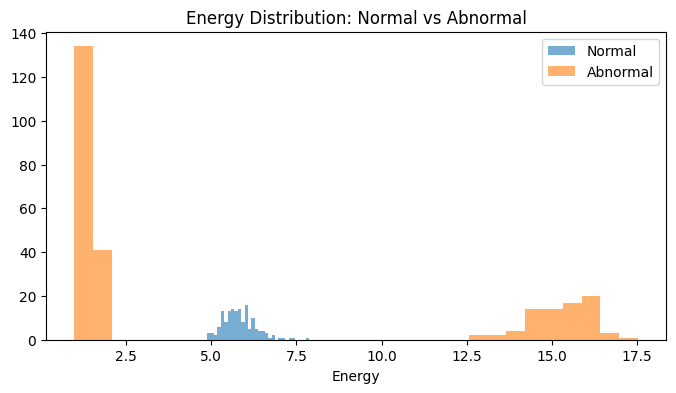

In [ ]:
import matplotlib.pyplot as plt

normal_rf_energy = []
abnormal_rf_energy = []

for file in normal_rf:
    y, sr = librosa.load(file, sr=SR)
    normal_rf_energy.append(np.sum(y**2))

for file in abnormal_rf:
    y, sr = librosa.load(file, sr=SR)
    abnormal_rf_energy.append(np.sum(y**2))

plt.figure(figsize=(8,4))
plt.hist(normal_rf_energy, bins=30, alpha=0.6, label='Normal')
plt.hist(abnormal_rf_energy, bins=30, alpha=0.6, label='Abnormal')
plt.xlabel("Energy")
plt.legend()
plt.title("Energy Distribution: Normal vs Abnormal")
plt.show()

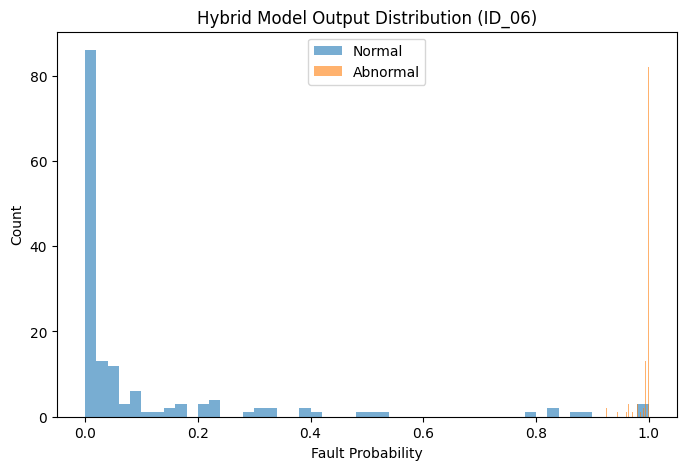

In [ ]:
import matplotlib.pyplot as plt

# predicted probability of abnormal
prob = rf_model.predict_proba(X_test)[:,1]

# split by label
normal_prob = prob[y_test == 0]
abnormal_prob = prob[y_test == 1]

plt.figure(figsize=(8,5))

plt.hist(normal_prob, bins=50, alpha=0.6, label="Normal")
plt.hist(abnormal_prob, bins=50, alpha=0.6, label="Abnormal")

plt.xlabel("Fault Probability")
plt.ylabel("Count")
plt.title("Hybrid Model Output Distribution (ID_06)")

plt.legend()
plt.show()

In [ ]:
len(y_test)

113

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[143  10]
 [  0 109]]


In [ ]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.9159663865546218


In [ ]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 1.0


In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.9940828402366864


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9911504424778761


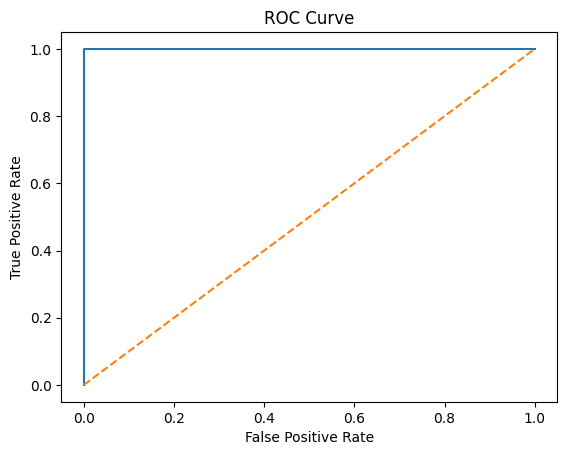

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [ ]:
print("Train examples:", len(train_normal_files))
print("Test normal examples:", len(test_normal_files))
print("Abnormal examples:", len(abnormal_files))

Train examples: 812
Test normal examples: 203
Abnormal examples: 361


In [ ]:
print("Normal error min:", error_normal.min())
print("Normal error max:", error_normal.max())

print("Abnormal error min:", error_abnormal.min())
print("Abnormal error max:", error_abnormal.max())

Normal error min: 0.032151915
Normal error max: 0.03754754
Abnormal error min: 0.03313287
Abnormal error max: 0.049958065


## TFLITE SECTION

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("model_id_06.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# IMPORTANT SETTINGS
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,      # standard TFLite ops
    tf.lite.OpsSet.SELECT_TF_OPS         # allow TF ops like Conv2D fallback
]

converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

with open("model_id_06.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model created successfully")

Saved artifact at '/tmp/tmp2rlabt7e'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None)
Captures:
  136039545303120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136039545303312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136039545304272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136039545303504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136039545304656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136039545304464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136039545305040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136039545304848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136039545305424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136039545305232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13603

In [ ]:
import numpy as np
import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path="model_id_06.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input shape:", input_details[0]['shape'])

Input shape: [  1 128 128   1]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
def tflite_predict(data):

    preds = []

    for i in range(len(data)):

        sample = data[i:i+1].astype(np.float32)

        interpreter.set_tensor(input_details[0]['index'], sample)

        interpreter.invoke()

        output = interpreter.get_tensor(output_details[0]['index'])

        preds.append(output[0])

    return np.array(preds)

In [ ]:
recon_normal_tflite = tflite_predict(X_test_normal)
recon_abnormal_tflite = tflite_predict(X_test_abnormal)

KeyboardInterrupt: 

In [ ]:
error_normal_tflite = np.mean(
    np.abs(X_test_normal - recon_normal_tflite),
    axis=(1,2,3)
)

error_abnormal_tflite = np.mean(
    np.abs(X_test_abnormal - recon_abnormal_tflite),
    axis=(1,2,3)
)

In [ ]:
from sklearn.metrics import roc_auc_score

y_true = np.concatenate([
    np.zeros(len(error_normal_tflite)),
    np.ones(len(error_abnormal_tflite))
])

y_scores = np.concatenate([
    error_normal_tflite,
    error_abnormal_tflite
])

auc_tflite = roc_auc_score(y_true, y_scores)

print("TFLite AUC:", auc_tflite)

## EVALUATION

In [ ]:
# ==========================================
# FULL ID EVALUATION (Counts + Metrics)
# ==========================================

import numpy as np
import glob
import os
import librosa
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report

# -----------------------------
# Configuration
# -----------------------------

BASE_PATH = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan"

SR = 16000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
IMG_WIDTH = 128


# -----------------------------
# Choose ID
# -----------------------------

id_name = "id_00"   # CHANGE HERE

print(f"\nEvaluating entire dataset for {id_name}")


# -----------------------------
# Load model + params
# -----------------------------

model = load_model(f"model_{id_name}.keras")
train_min = np.load(f"train_min_{id_name}.npy").item()
train_max = np.load(f"train_max_{id_name}.npy").item()
threshold = np.load(f"threshold_{id_name}.npy").item()


# -----------------------------
# Mel function
# -----------------------------

def extract_mel(file_path):
    y, sr = librosa.load(file_path, sr=SR)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] < IMG_WIDTH:
        pad = IMG_WIDTH - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0,0),(0,pad)), mode='constant')
    else:
        mel_db = mel_db[:, :IMG_WIDTH]

    return mel_db


# -----------------------------
# Load all files
# -----------------------------

id_path = os.path.join(BASE_PATH, id_name)

normal_files = glob.glob(os.path.join(id_path, "normal/*.wav"))
abnormal_files = glob.glob(os.path.join(id_path, "abnormal/*.wav"))

print("Normal files:", len(normal_files))
print("Abnormal files:", len(abnormal_files))


# -----------------------------
# Evaluate
# -----------------------------

y_true = []
y_pred = []

def predict_file(file_path):
    mel = extract_mel(file_path)
    mel = (mel - train_min) / (train_max - train_min)
    mel = mel[..., np.newaxis]
    mel = np.expand_dims(mel, axis=0)

    recon = model.predict(mel, verbose=0)
    error = np.mean(np.abs(mel - recon))

    return 1 if error > threshold else 0


# Evaluate normal files
for file in normal_files:
    y_true.append(0)
    y_pred.append(predict_file(file))

# Evaluate abnormal files
for file in abnormal_files:
    y_true.append(1)
    y_pred.append(predict_file(file))


# -----------------------------
# Results
# -----------------------------

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(cm)

print("\nTrue Normal (TN):", tn)
print("False Alarm (FP):", fp)
print("Missed Fault (FN):", fn)
print("Correct Abnormal (TP):", tp)

print("\nTotal Abnormal Detected:", tp, "out of", len(abnormal_files))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


Evaluating entire dataset for id_00
Normal files: 1011
Abnormal files: 407

Confusion Matrix:
[[892 119]
 [121 286]]

True Normal (TN): 892
False Alarm (FP): 119
Missed Fault (FN): 121
Correct Abnormal (TP): 286

Total Abnormal Detected: 286 out of 407

Classification Report:
              precision    recall  f1-score   support

           0     0.8806    0.8823    0.8814      1011
           1     0.7062    0.7027    0.7044       407

    accuracy                         0.8307      1418
   macro avg     0.7934    0.7925    0.7929      1418
weighted avg     0.8305    0.8307    0.8306      1418



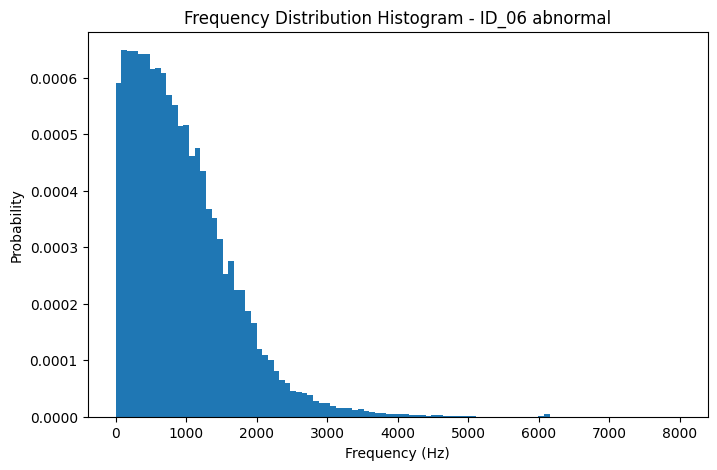

In [ ]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt

# path to one ID folder (example)
folder_path = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan/id_00/abnormal"

all_freqs = []

for file in os.listdir(folder_path):
    if file.endswith(".wav"):
        filepath = os.path.join(folder_path, file)

        # load audio
        y, sr = librosa.load(filepath, sr=None)

        # FFT
        fft = np.fft.rfft(y)
        magnitude = np.abs(fft)

        # corresponding frequencies
        freqs = np.fft.rfftfreq(len(y), d=1/sr)

        # keep frequencies with significant energy
        mask = magnitude > np.mean(magnitude)
        dominant_freqs = freqs[mask]

        all_freqs.extend(dominant_freqs)

# convert to numpy
all_freqs = np.array(all_freqs)

# plot histogram
plt.figure(figsize=(8,5))
plt.hist(all_freqs, bins=100, density=True)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Probability")
plt.title("Frequency Distribution Histogram - ID_06 abnormal")
plt.show()

In [ ]:
import os
import numpy as np
import librosa

folder = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan/id_00/abnormal"

dominant_freqs = []

for file in os.listdir(folder):

    y, sr = librosa.load(os.path.join(folder,file), sr=None)

    fft = np.fft.rfft(y)
    mag = np.abs(fft)
    freqs = np.fft.rfftfreq(len(y),1/sr)

    mask = (freqs>=1000) & (freqs<=3000)

    freqs = freqs[mask]
    mag = mag[mask]

    dominant = freqs[np.argmax(mag)]

    dominant_freqs.append(dominant)

print("Mean Dominant Frequency:",np.mean(dominant_freqs))
print("Std:",np.std(dominant_freqs))

Mean Dominant Frequency: 1263.8120393120394
Std: 224.78855142688644


In [ ]:
import os
import numpy as np
import librosa
import pandas as pd

folder = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan/id_06/normal"

centroids = []
bandwidths = []
energies = []

for file in os.listdir(folder):

    if file.endswith(".wav"):
        path = os.path.join(folder, file)

        y, sr = librosa.load(path, sr=None)

        # Spectral Centroid
        centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        centroids.append(np.mean(centroid))

        # Spectral Bandwidth
        bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        bandwidths.append(np.mean(bandwidth))

        # Energy
        energy = np.sum(y**2)
        energies.append(energy)

print("Spectral Centroid Mean:", np.mean(centroids))
print("Bandwidth Mean:", np.mean(bandwidths))
print("Energy Mean:", np.mean(energies))

Spectral Centroid Mean: 1512.705732350568
Bandwidth Mean: 1628.9956987805504
Energy Mean: 5.8689423


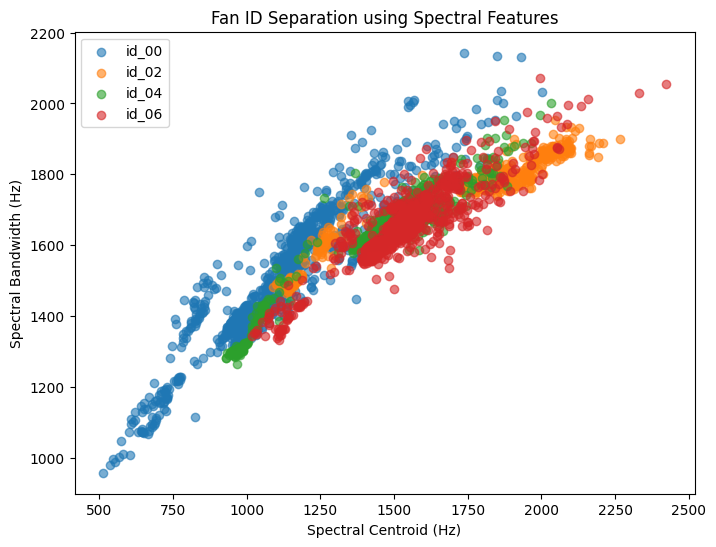

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# load your feature dataset
data = pd.read_csv("/content/fan_features.csv")

plt.figure(figsize=(8,6))

ids = data["id"].unique()

for fan_id in ids:

    subset = data[data["id"] == fan_id]

    plt.scatter(
        subset["centroid"],
        subset["bandwidth"],
        label=fan_id,
        alpha=0.6
    )

plt.xlabel("Spectral Centroid (Hz)")
plt.ylabel("Spectral Bandwidth (Hz)")
plt.title("Fan ID Separation using Spectral Features")

plt.legend()
plt.show()

In [ ]:
import pandas as pd

data = pd.read_csv("fan_features.csv")

summary = data.groupby(["id","condition"]).mean()

print(summary)

                 dominant_freq     centroid    bandwidth    energy
id    condition                                                   
id_00 abnormal     1263.812039  1020.252667  1439.519510  7.218596
      normal       1245.214936  1139.902041  1517.076266  3.486827
id_02 abnormal     1348.109192  1685.406473  1727.947797  3.618840
      normal       1539.959646  1800.231421  1776.967636  4.088205
id_04 abnormal     1210.839368  1352.604750  1566.371486  5.587926
      normal       1228.137367  1485.869248  1653.645445  3.687557
id_06 abnormal     1230.614404  1468.457893  1633.867227  5.477146
      normal       1139.973990  1512.705732  1628.995699  5.868943


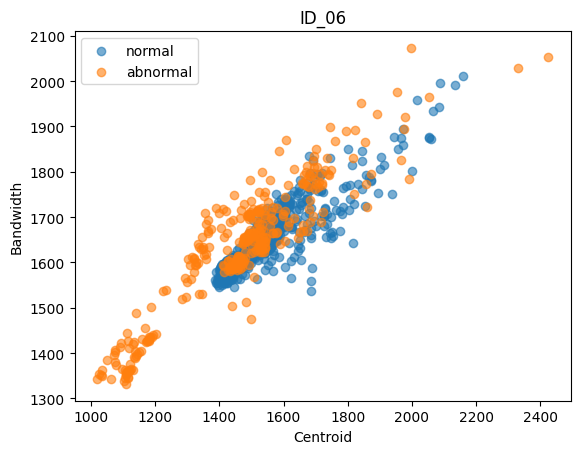

In [ ]:
import matplotlib.pyplot as plt

subset = data[data["id"]=="id_06"]

plt.scatter(
    subset[subset["condition"]=="normal"]["centroid"],
    subset[subset["condition"]=="normal"]["bandwidth"],
    label="normal",
    alpha=0.6
)

plt.scatter(
    subset[subset["condition"]=="abnormal"]["centroid"],
    subset[subset["condition"]=="abnormal"]["bandwidth"],
    label="abnormal",
    alpha=0.6
)

plt.legend()
plt.xlabel("Centroid")
plt.ylabel("Bandwidth")
plt.title("ID_06")
plt.show()

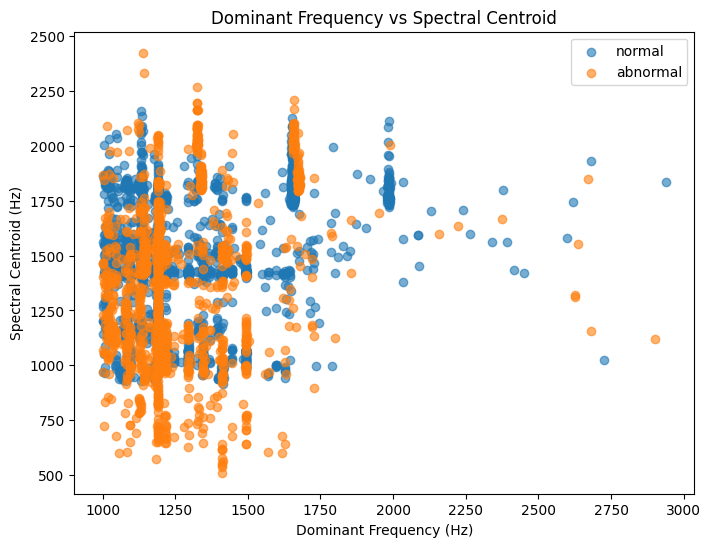

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("fan_features.csv")

plt.figure(figsize=(8,6))

normal = data[data["condition"]=="normal"]
abnormal = data[data["condition"]=="abnormal"]

plt.scatter(
    normal["dominant_freq"],
    normal["centroid"],
    alpha=0.6,
    label="normal"
)

plt.scatter(
    abnormal["dominant_freq"],
    abnormal["centroid"],
    alpha=0.6,
    label="abnormal"
)

plt.xlabel("Dominant Frequency (Hz)")
plt.ylabel("Spectral Centroid (Hz)")
plt.title("Dominant Frequency vs Spectral Centroid")

plt.legend()
plt.show()

In [ ]:
import os
import numpy as np
import librosa
import pandas as pd

base_path = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan"

ids = ["id_00","id_02","id_04","id_06"]
conditions = ["normal","abnormal"]

data = []

for fan_id in ids:

    for condition in conditions:

        folder = os.path.join(base_path,fan_id,condition)

        for file in os.listdir(folder):

            if file.endswith(".wav"):

                path = os.path.join(folder,file)

                y, sr = librosa.load(path,sr=None)

                # spectral centroid
                centroid = np.mean(librosa.feature.spectral_centroid(y=y,sr=sr))

                # bandwidth
                bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y,sr=sr))

                # energy
                energy = np.sum(y**2)

                # dominant frequency
                fft = np.fft.rfft(y)
                magnitude = np.abs(fft)
                freqs = np.fft.rfftfreq(len(y),1/sr)

                mask = (freqs>=1000) & (freqs<=3000)

                freqs = freqs[mask]
                magnitude = magnitude[mask]

                dominant = freqs[np.argmax(magnitude)]

                data.append([
                    fan_id,
                    condition,
                    dominant,
                    centroid,
                    bandwidth,
                    energy
                ])

df = pd.DataFrame(
    data,
    columns=[
        "id",
        "condition",
        "dominant_freq",
        "centroid",
        "bandwidth",
        "energy"
    ]
)

df.to_csv("fan_features.csv",index=False)

print("Feature dataset created")

KeyboardInterrupt: 

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib

# ==============================
# Load dataset
# ==============================

data = pd.read_csv("fan_features.csv")

# We only use spectral features
X = data[[
    "dominant_freq",
    "centroid",
    "bandwidth",
    "energy"
]]

# Target is fan ID
y = data["id"]

# ==============================
# Train/Test split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==============================
# Train Random Forest
# ==============================

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

# ==============================
# Evaluate
# ==============================

pred = model.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("Fan ID Classifier Accuracy:", accuracy)

# ==============================
# Save model
# ==============================

joblib.dump(model, "fan_id_classifier.pkl")

print("fan_id_classifier.pkl saved successfully")

In [ ]:
import numpy as np
import librosa
import joblib
from tensorflow.keras.models import load_model

# ==============================
# CONFIG
# ==============================

SR = 16000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
IMG_WIDTH = 128

audio_path = "/content/00000000.wav"


# ==============================
# LOAD FAN ID CLASSIFIER
# ==============================

id_classifier = joblib.load("fan_id_classifier.pkl")


# ==============================
# FEATURE EXTRACTION FOR ID
# ==============================

def extract_features(y, sr):

    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))

    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))

    energy = np.sum(y**2)

    fft = np.fft.rfft(y)
    mag = np.abs(fft)
    freqs = np.fft.rfftfreq(len(y), 1/sr)

    mask = (freqs >= 1000) & (freqs <= 3000)

    freqs = freqs[mask]
    mag = mag[mask]

    dominant = freqs[np.argmax(mag)]

    return centroid, bandwidth, energy, dominant


# ==============================
# MEL SPECTROGRAM
# ==============================

def extract_mel(y):

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] < IMG_WIDTH:
        pad = IMG_WIDTH - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0,0),(0,pad)), mode='constant')
    else:
        mel_db = mel_db[:, :IMG_WIDTH]

    return mel_db


# ==============================
# LOAD AUDIO
# ==============================

y, sr = librosa.load(audio_path, sr=SR)

centroid, bandwidth, energy, dom = extract_features(y, sr)

# features for ID classifier
id_features = np.array([[dom, centroid, bandwidth, energy]])

predicted_id = id_classifier.predict(id_features)[0]

print("\nDetected Fan ID:", predicted_id)


# ==============================
# LOAD CORRECT MODELS
# ==============================

autoencoder = load_model(f"model_{predicted_id}.keras")

fault_model = joblib.load(f"{predicted_id}_fault_model.pkl")

train_min = np.load(f"train_min_{predicted_id}.npy").item()
train_max = np.load(f"train_max_{predicted_id}.npy").item()


# ==============================
# AUTOENCODER INPUT
# ==============================

mel = extract_mel(y)

mel = (mel - train_min) / (train_max - train_min)

mel = mel[..., np.newaxis]
mel = np.expand_dims(mel, axis=0)


# ==============================
# RECONSTRUCTION ERROR
# ==============================

recon = autoencoder.predict(mel)

reconstruction_error = np.mean(np.abs(mel - recon))

print("Reconstruction Error:", reconstruction_error)


# ==============================
# HYBRID FAULT CLASSIFIER
# ==============================

fault_features = np.array([[

    reconstruction_error,
    centroid,
    bandwidth,
    energy,
    dom

]])

fault_prob = fault_model.predict_proba(fault_features)[0][1]

print("Fault Probability:", fault_prob)


# ==============================
# FINAL DECISION
# ==============================

if fault_prob > 0.5:

    print("\n⚠️ RESULT: FAN", predicted_id, "IS ABNORMAL")

else:

    print("\n✅ RESULT: FAN", predicted_id, "IS NORMAL")